In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

In [2]:
df = pd.read_csv('data/raw/5-loan_approval_dataset.csv')
print("Data load successfully!!!")

Data load successfully!!!


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [7]:
df.to_csv('data/process/loan_data_cleaned.csv')

## **1. Feature Engineering**

### 1.1. Total Assets Value

In [8]:
df["total_assets_value"] = (
    df["residential_assets_value"]
    + df["commercial_assets_value"]
    + df["luxury_assets_value"]
    + df["bank_asset_value"]
)

In [9]:
df['total_assets_value'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4269 entries, 0 to 4268
Series name: total_assets_value
Non-Null Count  Dtype
--------------  -----
4269 non-null   int64
dtypes: int64(1)
memory usage: 33.5 KB


In [10]:
sns.set_theme(style="darkgrid", palette="pastel")

In [11]:
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

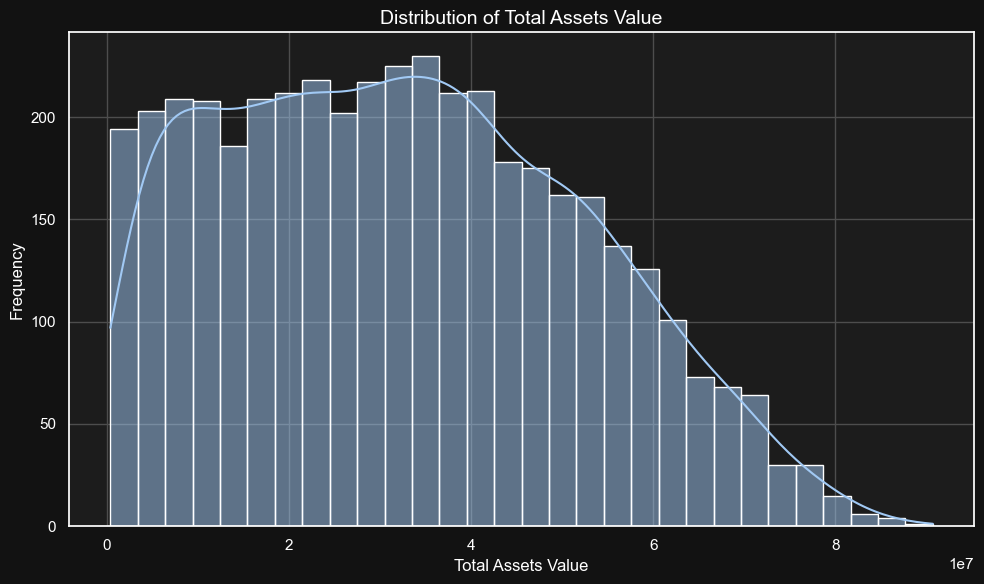

In [12]:
plt.figure(figsize=(10,6))
# Create a histogram with a Kernel Density Estimate (KDE) line
sns.histplot(x='total_assets_value', data=df, kde=True, color='b', bins=30)

# Set chart titles and labels
plt.title("Distribution of Total Assets Value", fontsize=14)
plt.xlabel("Total Assets Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("reports/images/feature_engineering/total_assets_value_distribution.png")
plt.show()

### 1.2. Loan To Income Ratio

In [13]:
df["loan_to_income_ratio"] = (
    df["loan_amount"] / df["income_annum"]
)

Ratio càng cao → rủi ro càng lớn

In [14]:
df['loan_to_income_ratio'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4269 entries, 0 to 4268
Series name: loan_to_income_ratio
Non-Null Count  Dtype  
--------------  -----  
4269 non-null   float64
dtypes: float64(1)
memory usage: 33.5 KB


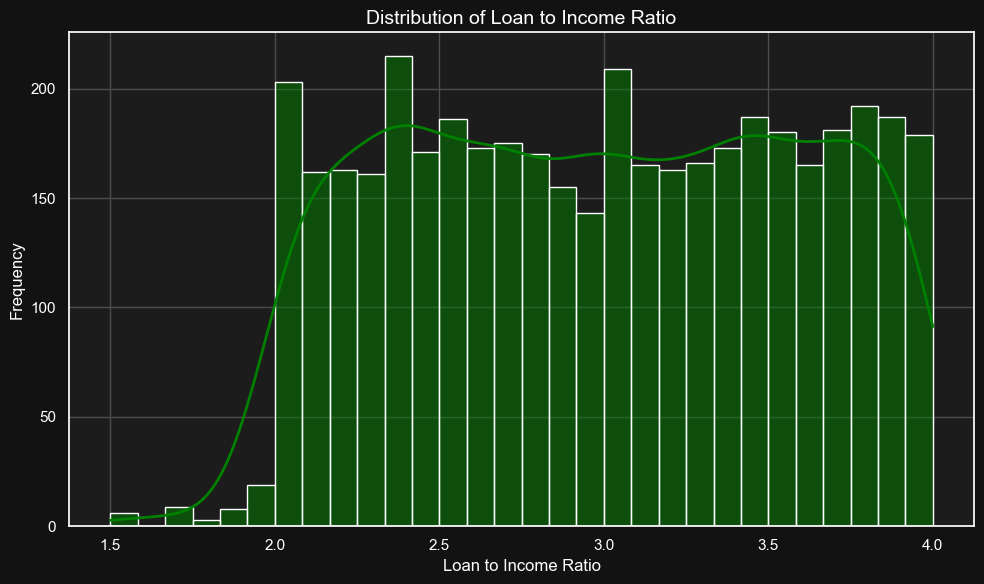

In [15]:
plt.figure(figsize=(10,6))

# Chỉnh KDE màu khác bằng line_kws
sns.histplot(
    x='loan_to_income_ratio', 
    data=df, 
    kde=True, 
    color='green',        
    line_kws={'lw': 2}, # Chỉnh đường KDE màu đỏ, độ dày (lw) là 2
    bins=30
)

plt.title("Distribution of Loan to Income Ratio", fontsize=14)
plt.xlabel("Loan to Income Ratio")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 1.3. Assets To Loan Ratio

In [16]:
df["assets_to_loan_ratio"] = (
    df["total_assets_value"] / df["loan_amount"]
)

Tài sản lớn hơn khoản vay → dễ được approve hơn

In [17]:
df['assets_to_loan_ratio'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4269 entries, 0 to 4268
Series name: assets_to_loan_ratio
Non-Null Count  Dtype  
--------------  -----  
4269 non-null   float64
dtypes: float64(1)
memory usage: 33.5 KB


In [18]:
df['assets_to_loan_ratio'].describe()

count    4269.000000
mean        2.231797
std         0.643145
min         0.750000
25%         1.767347
50%         2.142857
75%         2.616216
max         5.666667
Name: assets_to_loan_ratio, dtype: float64

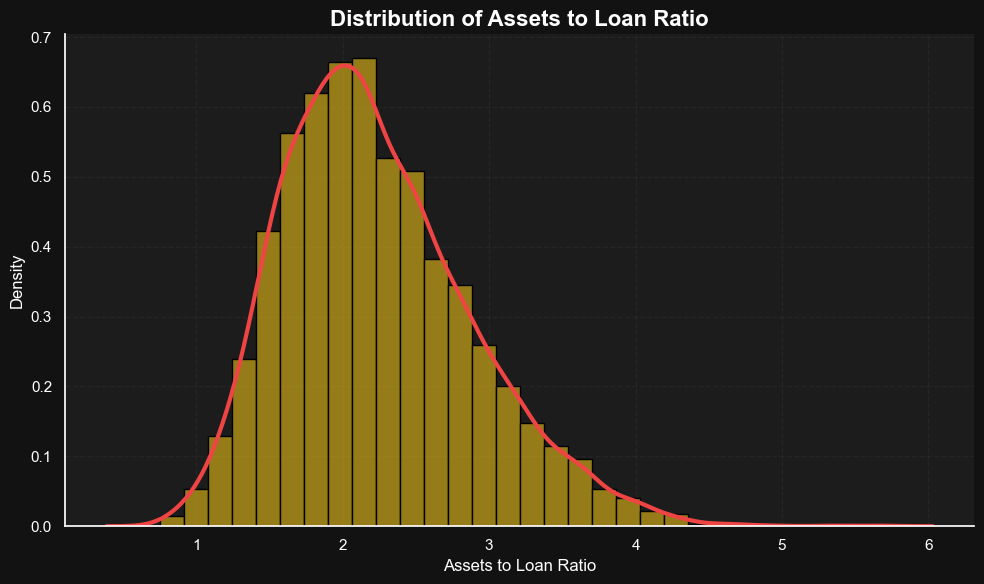

In [19]:
plt.figure(figsize=(10,6))
# Histogram
sns.histplot(
    data=df,
    x='assets_to_loan_ratio',
    bins=30,
    color='#facc15',
    alpha=0.55,
    edgecolor='black',
    stat='density'
)

# KDE riêng
sns.kdeplot(
    data=df,
    x='assets_to_loan_ratio',
    color='#ef4444',
    linewidth=3,
    fill=False
)

plt.title(
    "Distribution of Assets to Loan Ratio",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Assets to Loan Ratio", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(alpha=0.2, linestyle='--')

sns.despine()

plt.tight_layout()
plt.show()

### 1.4. Income Per Dependent

In [20]:
df["income_per_dependent"] = (
    df["income_annum"] / (df["no_of_dependents"] + 1)
)

Người phụ thuộc càng nhiều → áp lực tài chính càng cao

In [21]:
df['income_per_dependent'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4269 entries, 0 to 4268
Series name: income_per_dependent
Non-Null Count  Dtype  
--------------  -----  
4269 non-null   float64
dtypes: float64(1)
memory usage: 33.5 KB


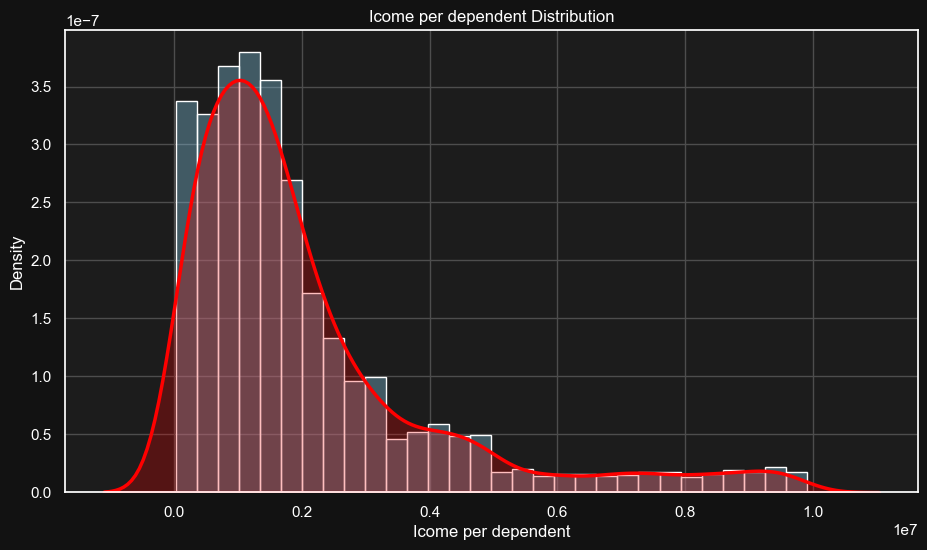

In [22]:
plt.figure(figsize=(11,6))

sns.histplot(
    data=df,
    x='income_per_dependent',
    bins=30,
    stat='density',
    color='skyblue',
    alpha=0.35
)

sns.kdeplot(
    data=df,
    x='income_per_dependent',
    fill=True,
    color='red',
    alpha=0.25,
    linewidth=2.5
)

plt.title("Icome per dependent Distribution")
plt.xlabel("Icome per dependent")
plt.show()

### 1.5. Loan Per Term

In [23]:
df["loan_per_term"] = (
    df["loan_amount"] / df["loan_term"]
)

Áp lực trả nợ trung bình mỗi năm

In [24]:
df['loan_per_term'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4269 entries, 0 to 4268
Series name: loan_per_term
Non-Null Count  Dtype  
--------------  -----  
4269 non-null   float64
dtypes: float64(1)
memory usage: 33.5 KB


In [25]:
df['loan_per_term'].describe()

count    4.269000e+03
mean     2.194899e+06
std      2.597537e+06
min      1.500000e+04
25%      7.000000e+05
50%      1.357143e+06
75%      2.516667e+06
max      1.935000e+07
Name: loan_per_term, dtype: float64

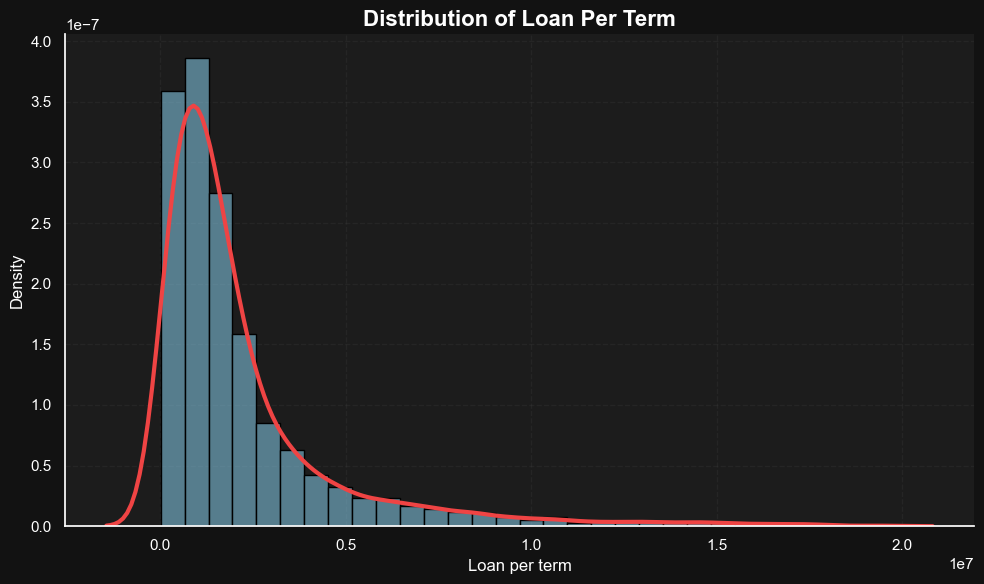

In [26]:
plt.figure(figsize=(10,6))
# Histogram
sns.histplot(
    data=df,
    x='loan_per_term',
    bins=30,
    color='skyblue',
    alpha=0.55,
    edgecolor='black',
    stat='density'
)

# KDE riêng
sns.kdeplot(
    data=df,
    x='loan_per_term',
    color='#ef4444',
    linewidth=3,
    fill=False
)

plt.title(
    "Distribution of Loan Per Term",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Loan per term", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(alpha=0.2, linestyle='--')

sns.despine()

plt.tight_layout()
plt.show()

## **2.Encoding**

### 2.1. Binary Encoding Education

In [27]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [28]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [29]:
df['education'] = df['education'].str.strip()

In [30]:
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [31]:
# Label Encoding
df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

In [32]:
df['education'].value_counts()

education
1    2144
0    2125
Name: count, dtype: int64

### 2.2. Binary Encoding self_employed

In [33]:
df['self_employed'].unique()

array([' No', ' Yes'], dtype=object)

In [34]:
df['self_employed'] = df['self_employed'].str.strip()

In [35]:
df['self_employed'].unique()

array(['No', 'Yes'], dtype=object)

In [36]:
df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

In [37]:
df['self_employed'].value_counts()

self_employed
1    2150
0    2119
Name: count, dtype: int64

### 2.3. Binary Encoding loan_status

In [38]:
df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [39]:
df['loan_status'] = df['loan_status'].str.strip()

In [40]:
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [41]:
df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   int64  
 1   no_of_dependents          4269 non-null   int64  
 2   education                 4269 non-null   int64  
 3   self_employed             4269 non-null   int64  
 4   income_annum              4269 non-null   int64  
 5   loan_amount               4269 non-null   int64  
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   int64  
 9   commercial_assets_value   4269 non-null   int64  
 10  luxury_assets_value       4269 non-null   int64  
 11  bank_asset_value          4269 non-null   int64  
 12  loan_status               4269 non-null   int64  
 13  total_assets_value        4269 non-null   int64  
 14  loan_to_

In [43]:
df.to_csv('data/process/loan_data_cleaned.csv', index=False)